# 03 · Análise Exploratória (EDA) com foco em negócio

**Tech Challenge Fase 1 · NPS Preditivo**

Este notebook responde às quatro perguntas do desafio, pensando em **um(a) gerente de operações que não entende estatística**:

1. Quais fatores parecem mais críticos para a satisfação?
2. O que mais gera detratores?
3. Existe algum "ponto de ruptura" na experiência do cliente?
4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

**Como ler os números:**
- **Nota média:** média das notas de 0 a 10 que os clientes deram.
- **% de detratores:** a cada 100 clientes, quantos deram nota abaixo de 7 (clientes insatisfeitos, que tendem a falar mal da marca).
- **NPS:** % de promotores (nota 9 ou 10) menos % de detratores. Vai de −100 (todos insatisfeitos) a +100 (todos fãs).

Base usada: `data/processed/nps_tratado.csv`, gerada no notebook `02_preparacao_dados.ipynb`.

## Configuração

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RAIZ_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(RAIZ_PROJETO))

from src.preparacao import calcular_nps, carregar_base_tratada  # noqa: E402

PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta única no projeto inteiro (os mesmos tons vão para os slides)
COR_DETRATOR = "#D1495B"
COR_NEUTRO = "#A0A4A8"
COR_PROMOTOR = "#2E9E6B"
COR_DESTAQUE = "#D1495B"
COR_BASE = "#6C8EBF"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = carregar_base_tratada()
print(f"{len(df)} pedidos carregados")

2500 pedidos carregados


In [2]:
def resumo_por_grupo(coluna_grupo: str) -> pd.DataFrame:
    """Quantidade de clientes, nota média, % de detratores e NPS de cada grupo."""
    agrupado = df.groupby(coluna_grupo, observed=True)
    return pd.DataFrame(
        {
            "clientes": agrupado.size(),
            "nota_media": agrupado["nps_score"].mean().round(1),
            "pct_detratores": (agrupado["flag_detrator"].mean() * 100).round(0),
            "nps": agrupado["nps_score"].apply(calcular_nps),
        }
    )


def salvar_figura(nome_arquivo: str) -> None:
    """Salva o gráfico em reports/figures para reaproveitar nos slides."""
    plt.tight_layout()
    plt.savefig(PASTA_FIGURAS / nome_arquivo, dpi=150, bbox_inches="tight")

## 0. Retrato atual: como está a satisfação hoje?

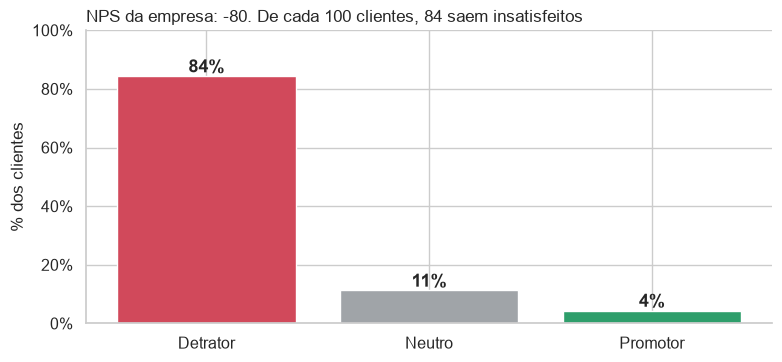

In [3]:
nps_geral = calcular_nps(df["nps_score"])
distribuicao = df["nps_categoria"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 3.8))
barras = ax.bar(
    distribuicao.index, distribuicao.values, color=[COR_DETRATOR, COR_NEUTRO, COR_PROMOTOR]
)
ax.bar_label(
    barras, labels=[f"{v:.0f}%" for v in distribuicao.values], fontsize=13, fontweight="bold"
)
ax.set_title(
    f"NPS da empresa: {nps_geral:.0f}. "
    f"De cada 100 clientes, {distribuicao['Detrator']:.0f} saem insatisfeitos",
    loc="left",
    fontsize=12,
)
ax.set_ylabel("% dos clientes")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
salvar_figura("03_01_retrato_nps.png")
plt.show()

**Para o gerente:** a situação é crítica. **84 de cada 100 clientes** saem insatisfeitos e só **4** viram fãs da marca. O NPS de **−80** está muito abaixo do que se considera saudável no varejo (em geral, acima de zero já é razoável e acima de +50 é excelente).

## 1. Quais fatores parecem mais críticos para a satisfação?

Medimos a **força da relação** de cada informação da operação com a nota do cliente. A escala vai de 0 (nenhuma relação) a 1 (relação perfeita). Estatisticamente é o módulo da correlação de Pearson, mas o gerente só precisa saber que **barra maior = fator que mais mexe com a nota**.

> `csat_internal_score` e `repeat_purchase_30d` ficam de fora: são **outras medidas da satisfação**, não causas dela (ver notebook 02).

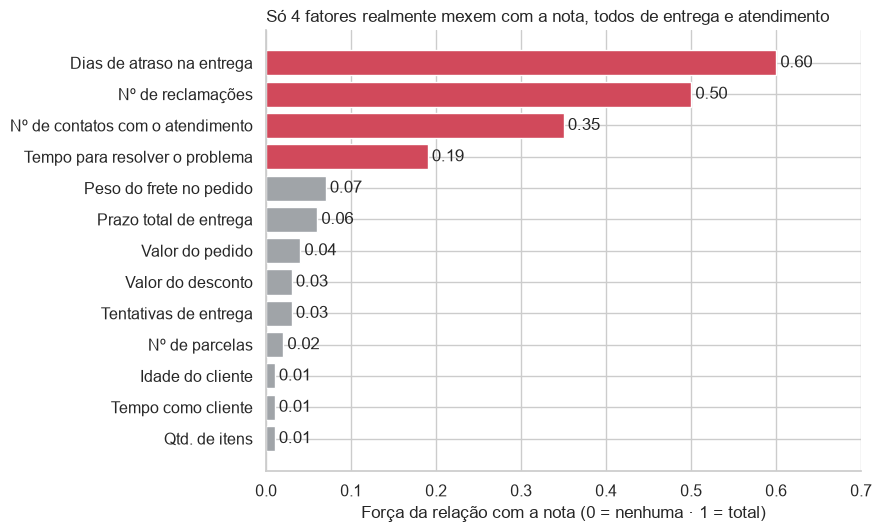

,fator,area,correlacao,forca_relacao
0,Dias de atraso na entrega,Logística,-0.597,0.60
1,Nº de reclamações,Atendimento,-0.497,0.50
2,Nº de contatos com o atendimento,Atendimento,-0.351,0.35
3,Tempo para resolver o problema,Atendimento,-0.191,0.19
4,Peso do frete no pedido,Pedido,-0.067,0.07
5,Prazo total de entrega,Logística,-0.060,0.06
6,Valor do pedido,Pedido,0.037,0.04
7,Tentativas de entrega,Logística,0.028,0.03
8,Valor do desconto,Pedido,0.025,0.03
9,Nº de parcelas,Pedido,0.024,0.02


In [4]:
FATORES = {
    "delivery_delay_days": ("Dias de atraso na entrega", "Logística"),
    "complaints_count": ("Nº de reclamações", "Atendimento"),
    "customer_service_contacts": ("Nº de contatos com o atendimento", "Atendimento"),
    "resolution_time_days": ("Tempo para resolver o problema", "Atendimento"),
    "pct_frete": ("Peso do frete no pedido", "Pedido"),
    "delivery_time_days": ("Prazo total de entrega", "Logística"),
    "delivery_attempts": ("Tentativas de entrega", "Logística"),
    "order_value": ("Valor do pedido", "Pedido"),
    "payment_installments": ("Nº de parcelas", "Pedido"),
    "discount_value": ("Valor do desconto", "Pedido"),
    "items_quantity": ("Qtd. de itens", "Pedido"),
    "customer_age": ("Idade do cliente", "Perfil"),
    "customer_tenure_months": ("Tempo como cliente", "Perfil"),
}

correlacoes = df[list(FATORES) + ["nps_score"]].corr()["nps_score"].drop("nps_score")
ranking = pd.DataFrame(
    {
        "fator": [FATORES[c][0] for c in correlacoes.index],
        "area": [FATORES[c][1] for c in correlacoes.index],
        "correlacao": correlacoes.values.round(3),
        "forca_relacao": correlacoes.abs().values.round(2),
    }
).sort_values("forca_relacao", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
cores = [COR_DESTAQUE if f >= 0.15 else COR_NEUTRO for f in ranking["forca_relacao"]]
barras = ax.barh(ranking["fator"], ranking["forca_relacao"], color=cores)
ax.bar_label(barras, labels=[f"{v:.2f}" for v in ranking["forca_relacao"]], padding=3)
ax.set_title(
    "Só 4 fatores realmente mexem com a nota, todos de entrega e atendimento",
    loc="left",
    fontsize=12,
)
ax.set_xlabel("Força da relação com a nota (0 = nenhuma · 1 = total)")
ax.set_xlim(0, 0.7)
salvar_figura("03_02_ranking_fatores.png")
plt.show()

ranking.sort_values("forca_relacao", ascending=False).reset_index(drop=True)

**Para o gerente:** quatro fatores concentram praticamente toda a relação com a satisfação, e **todos acontecem depois que o cliente clica em "comprar"**:

| # | Fator | Área responsável |
|---|---|---|
| 1 | **Atraso na entrega** | Logística |
| 2 | **Reclamações** | Atendimento / Qualidade |
| 3 | **Contatos repetidos com o atendimento** | Atendimento |
| 4 | **Demora para resolver o problema** | Atendimento |

Já preço, desconto, parcelamento, frete, quantidade de itens, idade e tempo de casa **praticamente não fazem diferença**. Os quatro fatores têm relação **negativa**: quanto mais atraso, reclamação ou contato, menor a nota.

### Um detalhe que muda a estratégia: prazo longo ≠ atraso

O **prazo total** de entrega quase não afeta a nota (0,06), mas o **atraso** é o fator nº 1 (0,60). Comparando lado a lado:

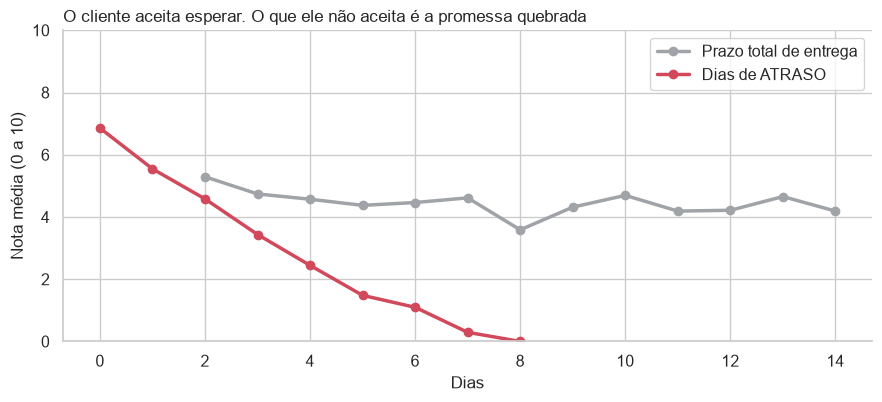

In [5]:
nota_por_prazo = df.groupby("delivery_time_days")["nps_score"].mean()
nota_por_atraso = df.groupby("delivery_delay_days")["nps_score"].mean()

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(
    nota_por_prazo.index,
    nota_por_prazo.values,
    "o-",
    color=COR_NEUTRO,
    lw=2.5,
    label="Prazo total de entrega",
)
ax.plot(
    nota_por_atraso.index,
    nota_por_atraso.values,
    "o-",
    color=COR_DESTAQUE,
    lw=2.5,
    label="Dias de ATRASO",
)
ax.set_title(
    "O cliente aceita esperar. O que ele não aceita é a promessa quebrada", loc="left", fontsize=12
)
ax.set_xlabel("Dias")
ax.set_ylabel("Nota média (0 a 10)")
ax.set_ylim(0, 10)
ax.legend()
salvar_figura("03_03_prazo_vs_atraso.png")
plt.show()

**Para o gerente:** um cliente que recebe em **14 dias, dentro do prometido**, dá praticamente a mesma nota de quem recebe em 2 dias. Já cada dia de **atraso** derruba a nota. A lição é **prometer um prazo que dá para cumprir**, e não necessariamente entregar mais rápido.

## 2. O que mais gera detratores?

Olhamos agora o **% de detratores** em cada situação: a cada 100 clientes naquela situação, quantos saem insatisfeitos.

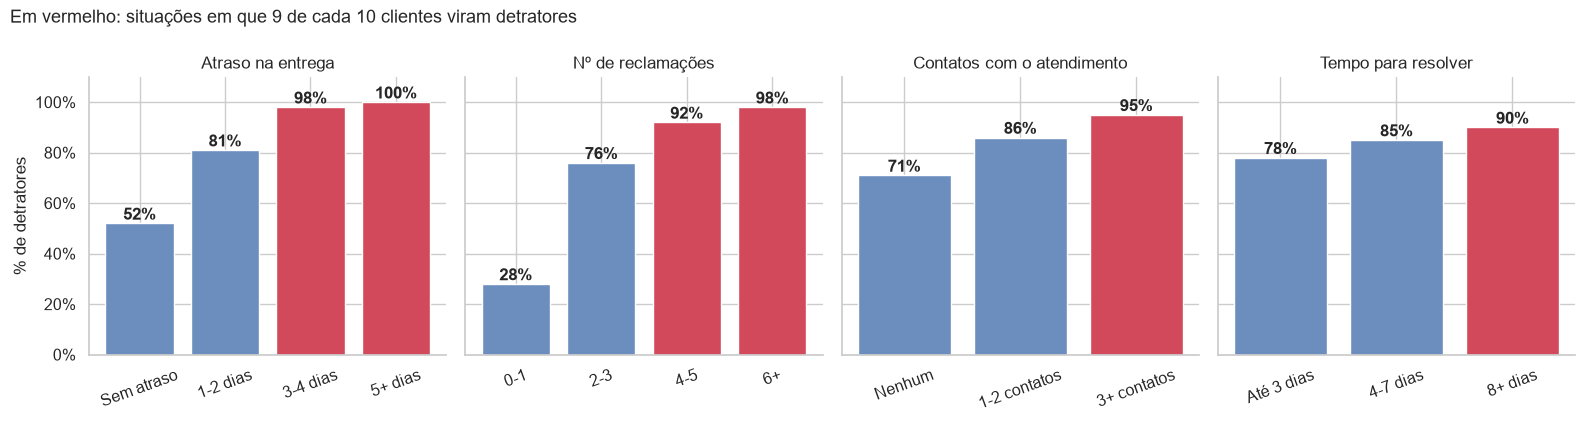

In [6]:
df["faixa_reclamacoes"] = pd.cut(
    df["complaints_count"], bins=[-1, 1, 3, 5, np.inf], labels=["0-1", "2-3", "4-5", "6+"]
)
df["faixa_resolucao"] = pd.cut(
    df["resolution_time_days"],
    bins=[-1, 3, 7, np.inf],
    labels=["Até 3 dias", "4-7 dias", "8+ dias"],
)

paineis = [
    ("faixa_atraso", "Atraso na entrega"),
    ("faixa_reclamacoes", "Nº de reclamações"),
    ("faixa_contatos", "Contatos com o atendimento"),
    ("faixa_resolucao", "Tempo para resolver"),
]

fig, eixos = plt.subplots(1, 4, figsize=(16, 4.3), sharey=True)
for eixo, (coluna, titulo) in zip(eixos, paineis):
    tabela = resumo_por_grupo(coluna)
    cores = [COR_DESTAQUE if p >= 90 else COR_BASE for p in tabela["pct_detratores"]]
    barras = eixo.bar(tabela.index.astype(str), tabela["pct_detratores"], color=cores)
    eixo.bar_label(
        barras, labels=[f"{v:.0f}%" for v in tabela["pct_detratores"]], fontweight="bold"
    )
    eixo.set_title(titulo)
    eixo.set_ylim(0, 110)
    eixo.yaxis.set_major_formatter(mtick.PercentFormatter())
    eixo.tick_params(axis="x", rotation=20)
eixos[0].set_ylabel("% de detratores")
fig.suptitle(
    "Em vermelho: situações em que 9 de cada 10 clientes viram detratores",
    x=0.01,
    ha="left",
    fontsize=13,
)
salvar_figura("03_04_geradores_detratores.png")
plt.show()

In [7]:
for coluna, titulo in paineis:
    print(f"--- {titulo} ---")
    display(resumo_por_grupo(coluna))

--- Atraso na entrega ---


,clientes,nota_media,pct_detratores,nps
faixa_atraso,,,,
Sem atraso,277,6.9,52.0,-33.6
1-2 dias,1261,5.1,81.0,-76.6
3-4 dias,795,3.1,98.0,-97.2
5+ dias,167,1.3,100.0,-100.0


--- Nº de reclamações ---


,clientes,nota_media,pct_detratores,nps
faixa_reclamacoes,,,,
0-1,145,7.9,28.0,-4.1
2-3,784,5.3,76.0,-69.0
4-5,1044,4.0,92.0,-89.9
6+,527,2.8,98.0,-97.3


--- Contatos com o atendimento ---


,clientes,nota_media,pct_detratores,nps
faixa_contatos,,,,
Nenhum,554,5.5,71.0,-60.5
1-2 contatos,1456,4.4,86.0,-82.6
3+ contatos,490,2.9,95.0,-94.3


--- Tempo para resolver ---


,clientes,nota_media,pct_detratores,nps
faixa_resolucao,,,,
Até 3 dias,866,4.9,78.0,-70.6
4-7 dias,792,4.4,85.0,-81.8
8+ dias,842,3.8,90.0,-87.9


**Para o gerente:**
- **Atraso:** sem atraso, metade dos clientes (52%) ainda sai insatisfeita. Com **3 dias ou mais**, **97 a 100%** saem insatisfeitos.
- **Reclamações:** quem registra 0 ou 1 reclamação tem NPS perto de zero (−4). A partir de **4 reclamações**, 92% viram detratores.
- **Contatos com o atendimento:** quem **não precisou** ligar tem NPS de −61. Com **3 ou mais contatos**, 95% são detratores. Cada vez que o cliente precisa voltar ao atendimento, a satisfação cai.
- **Tempo de resolução:** tem efeito menor, mas constante. Resolver em até 3 dias rende NPS de −71, contra −88 quando passa de uma semana.

### Os problemas se somam: o efeito bola de neve

Atraso e reclamações são problemas **quase independentes** (um não explica o outro). Quando acontecem juntos, o estrago se acumula:

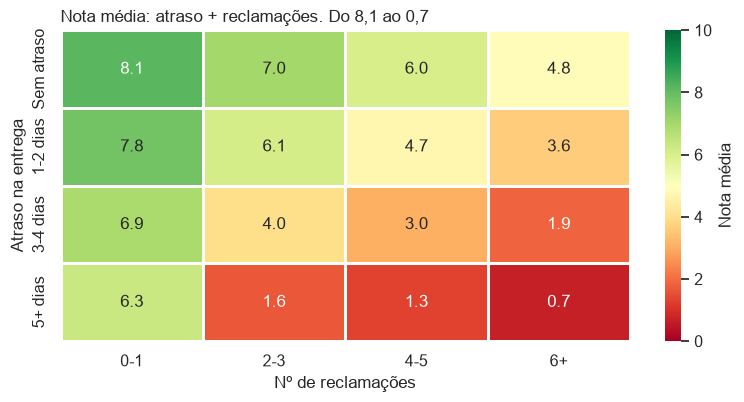

In [8]:
mapa_combinado = pd.crosstab(
    df["faixa_atraso"], df["faixa_reclamacoes"], values=df["nps_score"], aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.heatmap(
    mapa_combinado,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    vmin=0,
    vmax=10,
    cbar_kws={"label": "Nota média"},
    linewidths=1,
    ax=ax,
)
ax.set_title("Nota média: atraso + reclamações. Do 8,1 ao 0,7", loc="left", fontsize=12)
ax.set_xlabel("Nº de reclamações")
ax.set_ylabel("Atraso na entrega")
salvar_figura("03_05_efeito_combinado.png")
plt.show()

**Para o gerente:** o pedido **entregue no prazo e sem reclamação** recebe nota média **8,1**. O pedido **com 5+ dias de atraso e 6+ reclamações** recebe **0,7**. Resolver só um dos problemas já ajuda, mas o maior ganho vem de atacar os dois ao mesmo tempo.

## 3. Existe um "ponto de ruptura"?

Ponto de ruptura é o momento em que a experiência **deixa de ser recuperável**, quando praticamente todo cliente vira detrator.

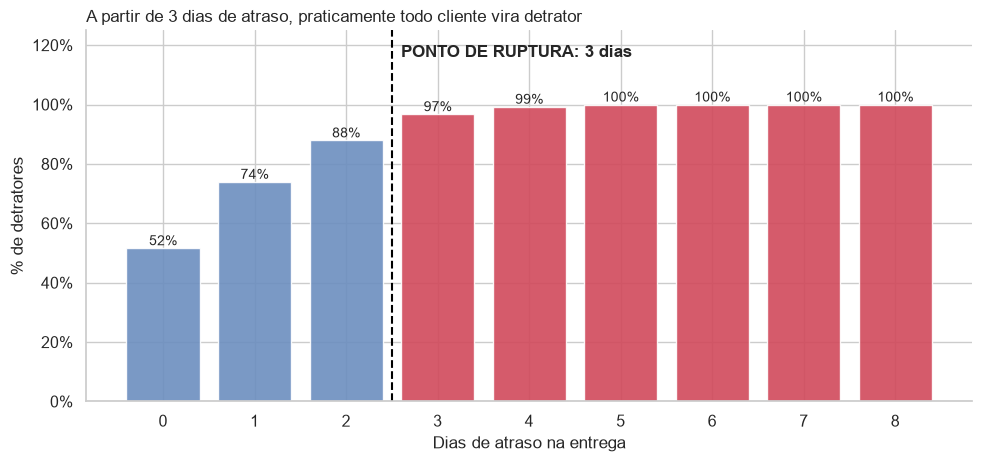

,clientes,nota_media,pct_detratores
delivery_delay_days,,,
0,277,6.9,51.6
1,615,5.5,74.0
2,646,4.6,87.9
3,525,3.4,96.8
4,270,2.4,99.3
5,116,1.5,100.0
6,34,1.1,100.0
7,14,0.3,100.0
8,3,0.0,100.0


In [9]:
por_dia_atraso = df.groupby("delivery_delay_days").agg(
    clientes=("nps_score", "size"),
    nota_media=("nps_score", "mean"),
    pct_detratores=("flag_detrator", "mean"),
)
por_dia_atraso["pct_detratores"] *= 100

fig, ax = plt.subplots(figsize=(10, 4.8))
cores = [COR_DESTAQUE if d >= 3 else COR_BASE for d in por_dia_atraso.index]
barras = ax.bar(por_dia_atraso.index, por_dia_atraso["pct_detratores"], color=cores, alpha=0.9)
ax.bar_label(barras, labels=[f"{v:.0f}%" for v in por_dia_atraso["pct_detratores"]], fontsize=10)
ax.axvline(2.5, color="black", ls="--", lw=1.5)
ax.text(2.6, 116, "PONTO DE RUPTURA: 3 dias", fontweight="bold")
ax.set_title(
    "A partir de 3 dias de atraso, praticamente todo cliente vira detrator", loc="left", fontsize=12
)
ax.set_xlabel("Dias de atraso na entrega")
ax.set_ylabel("% de detratores")
ax.set_ylim(0, 125)
ax.set_xticks(por_dia_atraso.index)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
salvar_figura("03_06_ponto_ruptura_atraso.png")
plt.show()

por_dia_atraso.round(1)

**Para o gerente:** existe sim um ponto de ruptura, e ele é claro.

- **0 a 2 dias de atraso:** a experiência ainda é recuperável. De 52% a 88% de detratores, subindo a cada dia.
- **3 dias ou mais:** **97% ou mais** viram detratores, e a partir de 5 dias são 100%. Nesse ponto não adianta mais agir: o cliente já decidiu.

Na prática, **a janela para agir é até o 2º dia de atraso**. Qualquer ação preventiva (avisar o cliente, oferecer compensação, priorizar a entrega) precisa acontecer **antes** do 3º dia.

O atendimento tem um salto parecido nas **reclamações**: com 0 ou 1 reclamação, cerca de 30% viram detratores, e **com 2 já são 65%**. Nos **contatos** a piora é gradual, sem um salto único, e passa de 90% a partir do 3º contato.

## 4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

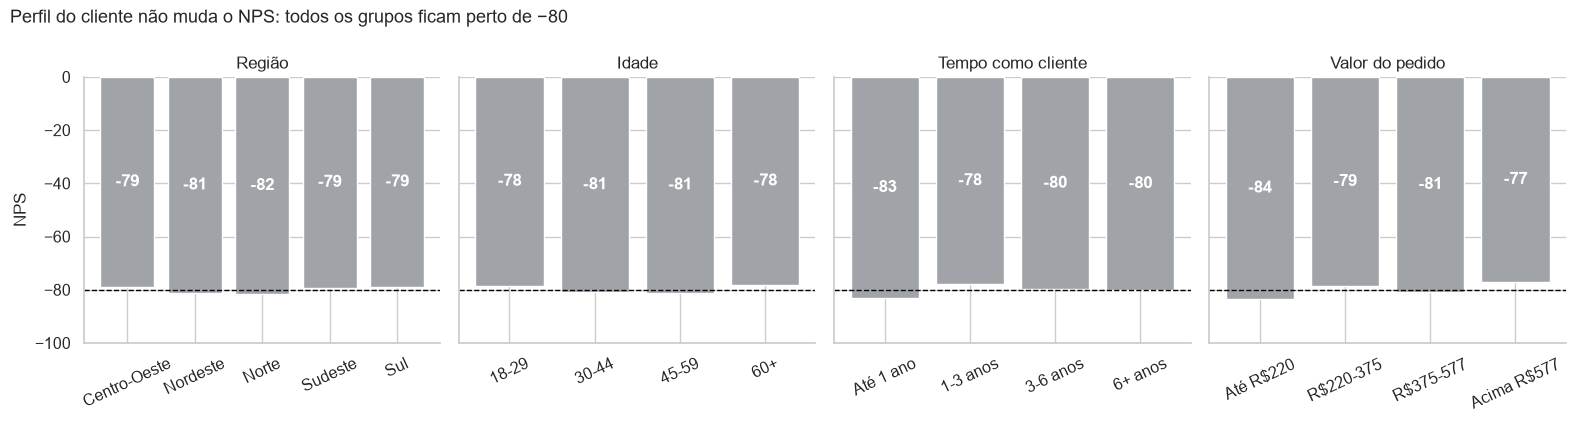

In [10]:
df["faixa_valor_pedido"] = pd.qcut(
    df["order_value"], 4, labels=["Até R$220", "R$220-375", "R$375-577", "Acima R$577"]
)

perfis = [
    ("customer_region", "Região"),
    ("faixa_idade", "Idade"),
    ("faixa_tempo_cliente", "Tempo como cliente"),
    ("faixa_valor_pedido", "Valor do pedido"),
]

fig, eixos = plt.subplots(1, 4, figsize=(16, 4.3), sharey=True)
for eixo, (coluna, titulo) in zip(eixos, perfis):
    tabela = resumo_por_grupo(coluna)
    barras = eixo.bar(tabela.index.astype(str), tabela["nps"], color=COR_NEUTRO)
    eixo.bar_label(
        barras,
        labels=[f"{v:.0f}" for v in tabela["nps"]],
        label_type="center",
        color="white",
        fontweight="bold",
    )
    eixo.axhline(nps_geral, color="black", ls="--", lw=1)
    eixo.set_title(titulo)
    eixo.set_ylim(-100, 0)
    eixo.tick_params(axis="x", rotation=25)
eixos[0].set_ylabel("NPS")
fig.suptitle(
    "Perfil do cliente não muda o NPS: todos os grupos ficam perto de −80",
    x=0.01,
    ha="left",
    fontsize=13,
)
salvar_figura("03_07_perfil_cliente.png")
plt.show()

In [11]:
for coluna, titulo in perfis:
    print(f"--- {titulo} ---")
    display(resumo_por_grupo(coluna))

--- Região ---


,clientes,nota_media,pct_detratores,nps
customer_region,,,,
Centro-Oeste,468,4.2,84.0,-78.8
Nordeste,485,4.4,86.0,-81.2
Norte,506,4.4,85.0,-81.6
Sudeste,520,4.4,84.0,-79.2
Sul,521,4.5,83.0,-78.9


--- Idade ---


,clientes,nota_media,pct_detratores,nps
faixa_idade,,,,
18-29,561,4.5,83.0,-78.4
30-44,753,4.3,86.0,-81.0
45-59,723,4.3,85.0,-81.2
60+,463,4.5,83.0,-78.2


--- Tempo como cliente ---


,clientes,nota_media,pct_detratores,nps
faixa_tempo_cliente,,,,
Até 1 ano,242,4.1,86.0,-83.1
1-3 anos,490,4.6,83.0,-78.0
3-6 anos,727,4.4,84.0,-79.9
6+ anos,1041,4.3,85.0,-80.2


--- Valor do pedido ---


,clientes,nota_media,pct_detratores,nps
faixa_valor_pedido,,,,
Até R$220,625,4.2,87.0,-83.5
R$220-375,625,4.5,84.0,-78.6
R$375-577,625,4.3,85.0,-80.8
Acima R$577,625,4.6,82.0,-77.0


**Para o gerente:** **não existe um "tipo de cliente" mais difícil.** Jovem ou idoso, Norte ou Sul, cliente novo ou antigo, compra pequena ou grande: todos ficam com NPS entre −77 e −84. Qualquer cliente fica satisfeito se a operação funciona, e qualquer cliente fica insatisfeito se ela falha.

O que diferencia os clientes é **a experiência que eles tiveram**:

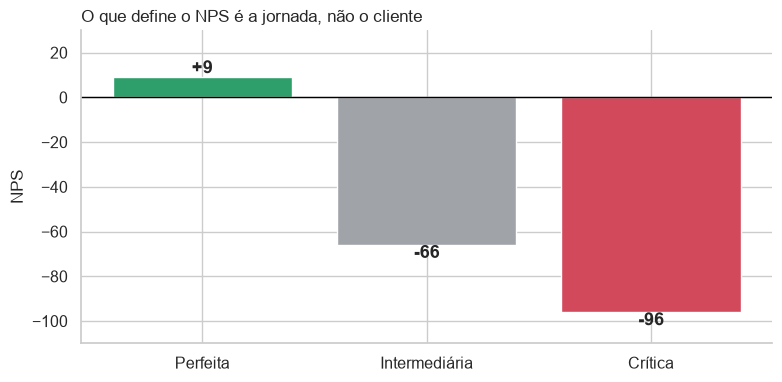

,clientes,nota_media,pct_detratores,nps,pct_clientes
tipo_jornada,,,,,
Perfeita,77,8.1,25.0,9.1,3.0
Intermediária,1065,5.7,73.0,-65.9,43.0
Crítica,1358,3.1,96.0,-96.0,54.0


In [12]:
jornada_perfeita = (
    (df["delivery_delay_days"] == 0)
    & (df["complaints_count"] <= 1)
    & (df["customer_service_contacts"] <= 1)
)
jornada_critica = (
    (df["delivery_delay_days"] >= 3)
    | (df["complaints_count"] >= 6)
    | (df["customer_service_contacts"] >= 3)
)

tipos_jornada = pd.Series("Intermediária", index=df.index)
tipos_jornada[jornada_critica] = "Crítica"
tipos_jornada[jornada_perfeita] = "Perfeita"
df["tipo_jornada"] = pd.Categorical(
    tipos_jornada, categories=["Perfeita", "Intermediária", "Crítica"], ordered=True
)

tabela_jornada = resumo_por_grupo("tipo_jornada")
tabela_jornada["pct_clientes"] = (tabela_jornada["clientes"] / len(df) * 100).round(0)

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(
    tabela_jornada.index.astype(str),
    tabela_jornada["nps"],
    color=[COR_PROMOTOR, COR_NEUTRO, COR_DETRATOR],
)
ax.bar_label(
    barras, labels=[f"{v:+.0f}" for v in tabela_jornada["nps"]], fontsize=13, fontweight="bold"
)
ax.axhline(0, color="black", lw=1)
ax.set_title("O que define o NPS é a jornada, não o cliente", loc="left", fontsize=12)
ax.set_ylabel("NPS")
ax.set_ylim(-110, 30)
salvar_figura("03_08_nps_por_jornada.png")
plt.show()

tabela_jornada

**Para o gerente:**
- **Jornada perfeita** (sem atraso, até 1 reclamação e até 1 contato): **NPS positivo (+9)**, mesmo nesta empresa. Só **3%** dos clientes têm essa experiência hoje.
- **Jornada crítica** (3+ dias de atraso, **ou** 6+ reclamações, **ou** 3+ contatos): NPS perto de **−100**, e ela atinge mais da metade da base.

A empresa **sabe** satisfazer o cliente quando a operação funciona. O problema é que isso acontece com pouca gente.

## 5. Por que isso importa para o caixa? NPS × recompra

Aqui usamos a coluna `repeat_purchase_30d`. Ela **não** explica a nota, porque acontece depois, mas mostra **o que o NPS vale em dinheiro**:

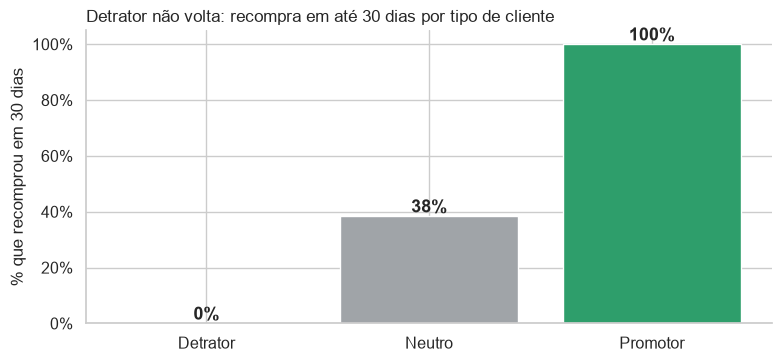

,clientes,nota_media,pct_detratores,nps
repeat_purchase_30d,,,,
Não recomprou,2282,3.9,92.0,-92.4
Recomprou,218,9.0,0.0,50.5


In [13]:
recompra_por_categoria = (
    df.groupby("nps_categoria", observed=True)["repeat_purchase_30d"].mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 3.8))
barras = ax.bar(
    recompra_por_categoria.index,
    recompra_por_categoria.values,
    color=[COR_DETRATOR, COR_NEUTRO, COR_PROMOTOR],
)
ax.bar_label(
    barras,
    labels=[f"{v:.0f}%" for v in recompra_por_categoria.values],
    fontsize=13,
    fontweight="bold",
)
ax.set_title(
    "Detrator não volta: recompra em até 30 dias por tipo de cliente", loc="left", fontsize=12
)
ax.set_ylabel("% que recomprou em 30 dias")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
salvar_figura("03_09_recompra_por_categoria.png")
plt.show()

resumo_por_grupo("repeat_purchase_30d").rename(index={0: "Não recomprou", 1: "Recomprou"})

**Para o gerente:** **nenhum detrator voltou a comprar em 30 dias.** Toda a recompra veio de neutros e promotores. Cada cliente que a operação transforma em detrator é, na prática, **um cliente perdido**. Por isso melhorar o NPS não é só "imagem": é **receita recorrente**.

> Cuidado: isso mostra que as duas coisas andam juntas (correlação). Não prova sozinho que subir o NPS aumenta a recompra, mas é um forte indício.

## Resumo executivo: as respostas para o(a) gerente de operações

| Pergunta | Resposta |
|---|---|
| **Quais fatores são mais críticos?** | **Atraso na entrega** (nº 1), **reclamações**, **contatos repetidos com o atendimento** e **demora na resolução**. Preço, frete, desconto e parcelamento quase não pesam. |
| **O que mais gera detratores?** | Atraso de 3+ dias (97–100% detratores), 4+ reclamações (92%+) e 3+ contatos (95%). Quando os problemas se combinam, a nota vai de 8,1 para 0,7. |
| **Existe ponto de ruptura?** | **Sim: 3 dias de atraso.** Até 2 dias ainda dá para recuperar o cliente, a partir de 3 praticamente todos viram detratores. No atendimento, o salto vem com a 2ª reclamação. |
| **Que cliente tem NPS mais alto ou mais baixo?** | **Nenhum perfil se destaca** (região, idade, tempo de casa e ticket dão todos ≈ −80). O que muda o NPS é a **jornada**: perfeita = **+9**, crítica = **≈ −100**. |

**Mensagem central:** a insatisfação não vem de *quem* é o cliente, e sim de *o que acontece* com o pedido dele. Com isso, o problema é **gerenciável pela operação**: cumprir o prazo prometido e resolver na primeira vez.

➡️ Os gráficos salvos em `reports/figures/` serão usados nos slides.